In [2]:
from sklearn.datasets import fetch_openml
import pandas as pd

adult = fetch_openml(name="adult", version=2, as_frame=True)
data = adult.frame   # a single DataFrame with all features AND the target column together

data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


# Mandatory Assignment - 2
## Exercise-1: Data Preparation
### Q1.1
 Identify and quantify missing values per feature. Determine whether the missingness looks random or is concentrated in specific subgroups (e.g., check if missing
occupation correlates with workclass). Choose and justify a strategy for handling
them (e.g., imputation vs. removal, and which imputation statistic), and explain
any risks your chosen strategy introduces.

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


Here we can see that there are some features that are missing some values.

In [4]:
missing = data.isna().sum()
missing_pct = (missing / len(data) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})[missing > 0]

,missing_count,missing_%
workclass,2799,5.73
occupation,2809,5.75
native-country,857,1.75


This shows us that there are some how many that are missing from each the features. 

In [5]:
pd.crosstab(data['workclass'].isna(), data['occupation'].isna())

occupation,False,True
workclass,,
False,46033,10
True,0,2799


By Cross-tabulating missing  `workclass` against missing `occupation`, 
shows us that the all the missing values from `workclass` (2799) are 
also missing in `occupation`. 

My hypothesis is that: individuals with no reported employment status 
naturally have no occupation to report either

A separate, much smaller group of 10 rows has occupation missing despite 
workclass being present, likely reflecting genuine non-response to that 
specific question rather than the same underlying cause.

The best solution to fix this issue is to impute/create a new explicit 
category ("Unknown" or "Not-in-workforce") rather than most-frequent-category 
or removing rows. This will prevent removing valueble information that might 
correlate later with income. I also see for my self that it is bad practice 
assigning hese individuals to whatever category happens to be most common. 

For `native-country` (only 1.75% missing), imputing with the mode 
("United-States", which dominates this column) is reasonable since the
missing fraction is small and unlikely to meaningfully bias results either way.


### Q1.3
Several categorical features are high-cardinality (e.g., native-country, occupation).
Quantify the cardinality of each categorical feature and propose a strategy for the
high-cardinality ones (e.g., grouping rare categories into an ”other” bucket, fre-
quency thresholding). Justify your chosen threshold and show how it changes the
category counts. 

In [6]:
cat_cols = data.select_dtypes(include='category').columns
cardinality = data[cat_cols].nunique().sort_values(ascending=False)
print(cardinality)

native-country    41
education         16
occupation        14
workclass          8
marital-status     7
relationship       6
race               5
sex                2
class              2
dtype: int64


Here can we see how many see how many `native-country` has a high-cardinality 
(Since it has 41 different categories). `Occupation` in the other hand has also 
a high cardinality, but less than the . 

The code bellow will show the categories and the count of each of `native-country` and `Occupation`: 


In [7]:
data['native-country'].value_counts(normalize=True).head(10) * 100

native-country
United-States    91.345212
Mexico            1.981869
Philippines       0.614775
Germany           0.429301
Puerto-Rico       0.383453
Canada            0.379285
El-Salvador       0.323018
India             0.314682
Cuba              0.287590
England           0.264666
Name: proportion, dtype: float64

In [8]:
data['native-country'].value_counts()

native-country
United-States                 43832
Mexico                          951
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru                             46
Ecuador      

From this we can see that the US alone accounts for around 90% of all rows,
While mexico has around 1-2%. The rest is under 1%. 

Lets try to reduse it to 3 category. This can be done by creating a threshold 
from 1%:

In [9]:
threshold = 0.01  # keep a category only if it makes up at least 1% of all rows

# get each country's share of the total rows (normalize=True gives proportions, not raw counts)
value_counts = data['native-country'].value_counts(normalize=True)

# countries below the threshold - these are the ones we'll group together
rare_categories = value_counts[value_counts < threshold].index

# create a new column: keep common countries as-is, replace rare ones with "Other"
data['native-country_grouped'] = data['native-country'].apply(
    lambda x: 'Other' if x in rare_categories else x
)


print("Before:", data['native-country'].nunique(), "categories")   # original number of countries
print("After: ", data['native-country_grouped'].nunique(), "categories")  # fewer, now that rare ones are merged
print("\nCategories after grouping:")
print(data['native-country_grouped'].value_counts())

Before: 41 categories
After:  3 categories

Categories after grouping:
native-country_grouped
United-States    43832
Other             3202
Mexico             951
Name: count, dtype: int64



Applying a 1% frequency threshold reduces `native-country` from 41 categories down to
just 3: `United-States` (43,832 rows, around 91%), `Other` (3,202 rows, grouping all
countries individually below 1%), and `Mexico` (951 rows, around 2%).

This removes countries with only a handful of rows each, which the model could barely
learn from anyway, and avoids the risk of a country showing up in the test set that
the model never saw during training.

The trade-off: countries like Germany or Canada, which might have their own real
income pattern, now get lumped into "Other" along with everyone else. Since each of
these groups is very small on its own, we're likely not losing much. But it's worth
knowing this simplification could hide a real pattern if one of these countries
mattered more than expected.

In [10]:
print(data['workclass'].unique(),"\n")
print(data['workclass'].value_counts())

['Private', 'Local-gov', NaN, 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked']
Categories (8, str): ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay'] 

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


### Q1.4

Encode the categorical features using an appropriate technique (e.g., one-hot encoding, target encoding, or ordinal encoding where suitable) and justify your choice.
Discuss how the encoding affects the dimensionality of the feature space, and how
it interacts with your high-cardinality strategy from the previous question.


For the nominal categorical features (`workclass`, `marital-status`, `occupation`,
`relationship`, `race`, `native-country_grouped`), **OneHotEncoder** is the most
appropriate choice.

None of these features have a natural order. For example, `workclass` values like
`Private`, `Self-emp-not-inc`, and `Federal-gov` aren't points on a scale, and the
same is true for the other features. Ordinal encoding would falsely imply an order
between them, for example, encoding `race` as 0-4 would suggest one category lies
"between" two others, which has no real meaning here. One-hot encoding avoids this by
giving each category its own independent binary column.

In [11]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# --- 1. Impute missing values (safe to re-run: checks before adding categories) ---
if 'Unknown' not in data['workclass'].cat.categories:
    data['workclass'] = data['workclass'].cat.add_categories('Unknown')
data['workclass'] = data['workclass'].fillna('Unknown')

if 'Unknown' not in data['occupation'].cat.categories:
    data['occupation'] = data['occupation'].cat.add_categories('Unknown')
data['occupation'] = data['occupation'].fillna('Unknown')

data['native-country'] = data['native-country'].fillna(data['native-country'].mode()[0])

print("Missing values after imputation:")
print(data[['workclass', 'occupation', 'native-country']].isna().sum())

# --- 2. Recreate native-country_grouped from the now-imputed native-country ---
threshold = 0.01
value_counts = data['native-country'].value_counts(normalize=True)
rare_categories = value_counts[value_counts < threshold].index
data['native-country_grouped'] = data['native-country'].apply(
    lambda x: 'Other' if x in rare_categories else x
)

# --- 3. Verify everything is clean before encoding ---
nominal_cols = ['workclass', 'marital-status', 'occupation',
                'relationship', 'race', 'native-country_grouped']
print("\nMissing values in nominal columns:")
print(data[nominal_cols].isna().sum())

# --- 4. One-hot encode ---
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_array = encoder.fit_transform(data[nominal_cols])

print("\nBefore encoding:", data[nominal_cols].shape[1], "columns")
print("After encoding: ", encoded_array.shape[1], "columns")

# --- 5. Assemble the final feature matrix X and target y ---
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(nominal_cols),
    index=data.index
)

sex_encoded = data['sex'].map({'Male': 0, 'Female': 1})

numeric_cols = data.select_dtypes(include='number').columns.tolist()
X = pd.concat([data[numeric_cols], sex_encoded.rename('sex'), encoded_df], axis=1)
y = data['class'].map({'<=50K': 0, '>50K': 1})

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)



Missing values after imputation:
workclass         0
occupation        0
native-country    0
dtype: int64

Missing values in nominal columns:
workclass                 0
marital-status            0
occupation                0
relationship              0
race                      0
native-country_grouped    0
dtype: int64

Before encoding: 6 columns
After encoding:  39 columns

Final X shape: (48842, 46)
Final y shape: (48842,)


After imputing missing values (since i nearly forgot to...) and grouping rare native-country categories, one-hot
encoding the 6 nominal features increases the feature space from 6 to 39 columns.
Adding the numeric features and the binary sex column gives a final feature matrix
with 46 columns. This shows why the native-country grouping mattered: without
reducing it from 41 to 3 categories first, one-hot encoding would have added about
40 extra columns from that feature alone.

##### Binary Feature Encoding: `class` and `sex`

Unlike the nominal features above, `class` (the target) and `sex` (a feature)
are each binary, they only take on two possible values. For these,
**one-hot encoding is unnecessary and wasteful**, so a direct mapping to 0/1
is used instead.

In [12]:
print(data['sex'].unique()) 

['Male', 'Female']
Categories (2, str): ['Female', 'Male']


In [13]:
data['sex'] = data['sex'].map({'Male': 0, 'Female': 1})

print(data['sex'].unique(), "\n")
print(data['sex'].value_counts())

[0, 1]
Categories (2, int64): [1, 0] 

sex
0    32650
1    16192
Name: count, dtype: int64


In [14]:
print(data['class'].unique(),"\n")
print(data['class'].value_counts())

['<=50K', '>50K']
Categories (2, str): ['<=50K', '>50K'] 

class
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [15]:
y = data['class'].map({'<=50K': 0, '>50K': 1})
X = data.drop(columns=['class'])

Why not one hot encode these too?

With only two categories, one hot encoding would create two columns that
mirror each other completely. For example, sex_Male and sex_Female would
always be opposite values, so one column already tells you the other. This
adds an extra column with no new information, increases dimensionality for
no reason, and creates multicollinearity, which is especially bad for
models like SVM that are sensitive to correlated features. A single 0/1
column keeps the same information using half the columns.

For class specifically, since it is the target variable and not an input
feature, it is never included in the encoding process applied to the
feature columns. It is mapped separately and stored as y, so it cannot
accidentally end up inside the feature matrix X, which would otherwise
cause target leakage.

Dimensionality impact: while one hot encoding increased the nominal
features from 6 columns to 40, mapping sex to 0/1 keeps it at exactly
1 column, the same as before encoding. This shows the main point of this
question clearly: the encoding method should match the structure of the
feature instead of using one hot encoding everywhere.

**Target encoding** is generally more useful for
features with very high cardinality, where one-hot would cause a large increase
in dimensionality. Since none of these features have that problem, especially
after grouping `native-country`, one-hot encoding is preferable: it is more
interpretable, avoids the target leakage risk inherent to target encoding, and
does not require additional safeguards like smoothing or cross-validation.

### Q1.5 
Compute a correlation matrix (or association measure suitable for mixed types,
e.g., Cramer’s V for categorical pairs) among the features. Plot it as a heatmap
and identify any pairs with strong multicollinearity. Discuss why multicollinearity
is a concern for a linear SVM but less so for a Decision Tree


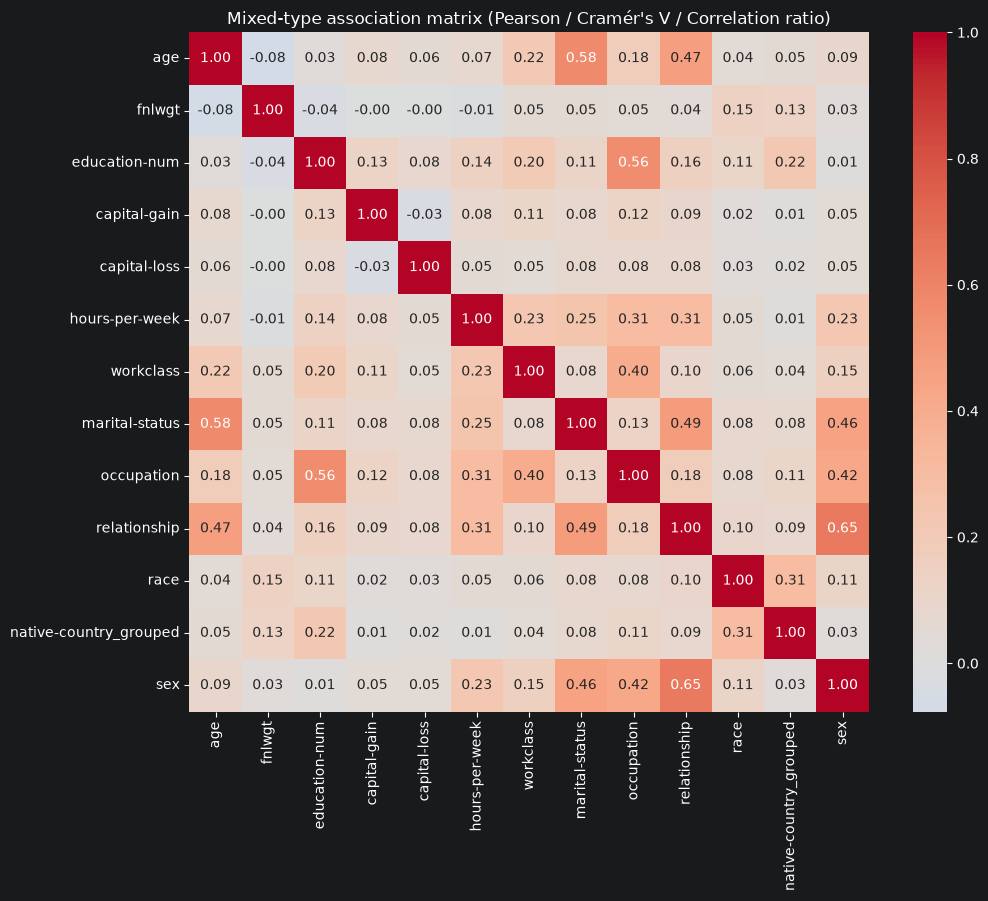

In [16]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

def correlation_ratio(categories, values):
    categories = pd.Series(categories)
    values = pd.Series(values)
    cat_means = values.groupby(categories).mean()
    overall_mean = values.mean()
    n_per_cat = categories.value_counts()
    ss_between = sum(n_per_cat[cat] * (mean - overall_mean) ** 2 for cat, mean in cat_means.items())
    ss_total = sum((values - overall_mean) ** 2)
    return np.sqrt(ss_between / ss_total)

numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country_grouped', 'sex']

all_cols = numeric_cols + categorical_cols
assoc_matrix = pd.DataFrame(index=all_cols, columns=all_cols, dtype=float)

for col1 in all_cols:
    for col2 in all_cols:
        if col1 == col2:
            assoc_matrix.loc[col1, col2] = 1.0
        elif col1 in numeric_cols and col2 in numeric_cols:
            assoc_matrix.loc[col1, col2] = data[col1].corr(data[col2])
        elif col1 in categorical_cols and col2 in categorical_cols:
            assoc_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])
        else:
            num_col, cat_col = (col1, col2) if col1 in numeric_cols else (col2, col1)
            assoc_matrix.loc[col1, col2] = correlation_ratio(data[cat_col], data[num_col])

plt.figure(figsize=(11, 9))
sns.heatmap(assoc_matrix.astype(float), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Mixed-type association matrix (Pearson / Cramér\'s V / Correlation ratio)')
plt.tight_layout()
plt.show()

The strongest relationship in the matrix is between `relationship` and `sex` (0.65).
This makes sense: categories like `Husband` and `Wife` already tell you the person's
sex, so the two features overlap a lot.

A few other pairs also stand out, for reasons that make sense once you think about
them: `age` and `marital-status` (0.58) — older people are more likely to be married.
`education-num` and `occupation` (0.56) — certain jobs require more education.
`marital-status` and `relationship` (0.49) — both describe similar family info.

None of these are close to 1.0, so there's some multicollinearity here, but it's
moderate, not extreme.

**Why this matters more for SVM than Decision Trees:** A linear SVM builds its
decision boundary as a weighted combination of all features at once. If two features
like `relationship` and `sex` carry similar information, the model can struggle to
decide how much weight to give each one, making the result less stable. A Decision
Tree doesn't have this problem the same way, at each split, it just picks whichever
single feature works best *at that point*. If `sex` isn't useful for one split, it can
just use `relationship` instead, without needing to balance both at once.

### Q1.6 
Run a statistical test of association between each feature and the target (e.g., point-
biserial correlation or ANOVA F-test for numeric features, chi-square test for categorical features). 
Rank the top 8 features by statistical significance and compare
this ranking, qualitatively, to what you expect the feature importances in Exercise
2 to look like. 

In [17]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import f_classif
from scipy.stats import chi2_contingency

numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country_grouped', 'sex']

results = []

# --- Numeric features: ANOVA F-test against the binary target ---
F_stats, p_values = f_classif(data[numeric_cols], y)
for col, F, p in zip(numeric_cols, F_stats, p_values):
    results.append({'feature': col, 'test': 'ANOVA F', 'statistic': F, 'p_value': p})

# --- Categorical features: Chi-square test of independence against the target ---
for col in categorical_cols:
    contingency = pd.crosstab(data[col], y)
    chi2, p, dof, expected = chi2_contingency(contingency)
    results.append({'feature': col, 'test': 'Chi-square', 'statistic': chi2, 'p_value': p})

results_df = pd.DataFrame(results).sort_values('statistic', ascending=False)
print(results_df.head(8))

           feature        test     statistic  p_value
9     relationship  Chi-square  10088.722490      0.0
7   marital-status  Chi-square   9816.015037      0.0
2    education-num     ANOVA F   6075.369398      0.0
8       occupation  Chi-square   5983.163852      0.0
0              age     ANOVA F   2737.207112      0.0
5   hours-per-week     ANOVA F   2670.362124      0.0
3     capital-gain     ANOVA F   2556.179071      0.0
12             sex  Chi-square   2248.847679      0.0


With such a large dataset (about 48,842 rows), almost every feature comes back
"statistically significant" (very low p values), so p value alone doesn't help tell
features apart. Instead, we rank by the test statistic itself (F value or chi square
value): a bigger number means a stronger link to the target, regardless of sample
size.

We'd expect a lot of overlap between this ranking and the feature importances in
Exercise 2, since both measure the same basic thing: how well a feature separates
`<=50K` from `>50K` earners. Our top 8 (`relationship`, `marital-status`,
`education-num`, `occupation`, `age`, `hours-per-week`, `capital-gain`, and `sex`)
covers most of the features we'd expect a strong model to also rely on heavily.

One likely difference: `relationship` and `marital-status` rank 1st and 2nd here, but
we already found them fairly correlated (0.49 in Q1.5). A tree-based model might lean
on whichever one it happens to split on first near the root, making the other look
less important than this test suggests. This is similar to what happened with the
correlated ThermalConductivity features in the last assignment's Random Forest.

### Q1.7

Analyze the numerical features with and without standardization (zero mean, unit
variance). Plot the feature distributions with and without standardization, and
decide which version is more suitable for the models used in this assignment. 



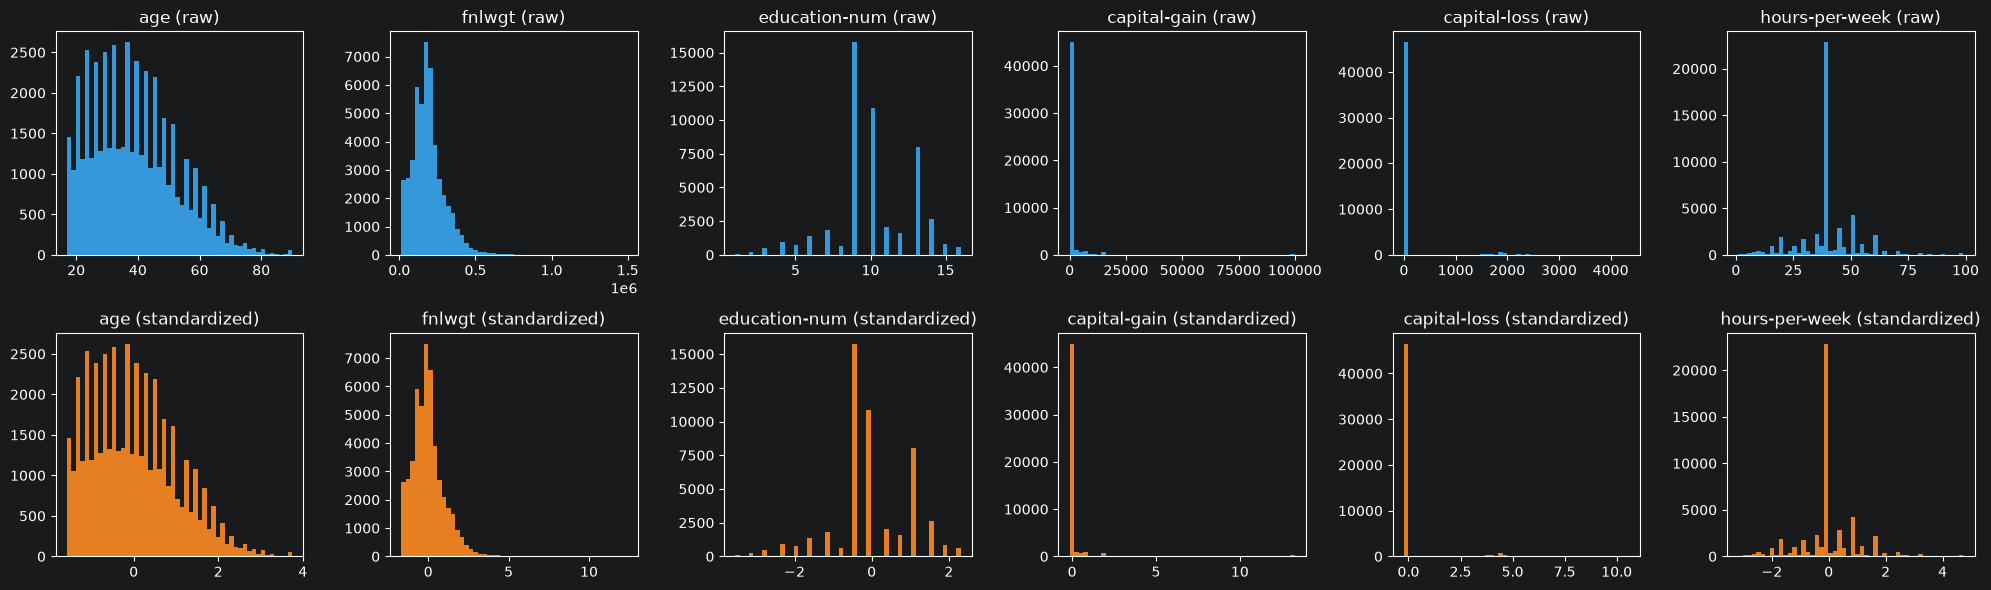

In [18]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
scaled = pd.DataFrame(StandardScaler().fit_transform(data[numeric_cols]), columns=numeric_cols)

fig, axes = plt.subplots(2, len(numeric_cols), figsize=(20, 6))
for i, col in enumerate(numeric_cols):
    axes[0, i].hist(data[col], bins=50, color='#3498db')
    axes[0, i].set_title(f'{col} (raw)')
    axes[1, i].hist(scaled[col], bins=50, color='#e67e22')
    axes[1, i].set_title(f'{col} (standardized)')
plt.tight_layout()
plt.show()

The plots show that standardization only changes the scale of the numbers, not the
shape of the distribution. `fnlwgt` shows this clearly: its raw values range from 0 to
about 1.5 million, but after scaling they compress down to roughly -1 to 12. This is
why SVM needs this step. Without it, fnlwgt's huge numbers would dominate distance
based calculations, even though its actual predictive value has nothing to do with
its size.

`capital-gain` and `capital-loss` stay heavily skewed even after standardization: most
values are still zero, with a few extreme outliers. This shows that scaling does not
fix skewness. Only a transform like log would do that, which is a separate issue from
the scaling question asked here.

### Q1.8 
Assemble your missing-value handling, outlier treatment, encoding, and standard-
ization steps into a single leak-free preprocessing pipeline (e.g., using ColumnTransformer
and Pipeline), fitted only on the training fold and applied unchanged to the val-
idation and test data. Explain, with a concrete example from your own pipeline,
how fitting any preprocessing step on the full dataset before splitting would cause
data leakage. 

In [19]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# --- 1. Load RAW data fresh (untouched by earlier manual preprocessing) ---
adult = fetch_openml(name="adult", version=2, as_frame=True)
raw_data = adult.frame

X = raw_data.drop(columns=['class'])
y = raw_data['class'].map({'<=50K': 0, '>50K': 1})

print(X['sex'].unique())   # sanity check: should print ['Male', 'Female'], raw strings (Ill keep this so i remember to check values like this in future)

# --- 2. 60/20/20 stratified split ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# --- 3. Custom outlier-capping transformer ---
class PercentileCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.quantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.quantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):        #  Used in the later questions
        return np.asarray(input_features)

# --- 4. Column groups ---
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
nominal_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
binary_cols = ['sex']

# --- 5. Sub-pipelines ---
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('cap', PercentileCapper(lower=0.01, upper=0.99)),
    ('scale', StandardScaler()),
])

nominal_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.01, drop='first')),
])

binary_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=[['Male', 'Female']])),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('nom', nominal_pipeline, nominal_cols),
    ('bin', binary_pipeline, binary_cols),
])

# --- 6. Fit ONLY on training data, apply unchanged to val/test ---
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed shapes:", X_train_processed.shape, X_val_processed.shape, X_test_processed.shape)

['Male', 'Female']
Categories (2, str): ['Female', 'Male']
Train: (29305, 14) Val: (9768, 14) Test: (9769, 14)
Processed shapes: (29305, 44) (9768, 44) (9769, 44)


In [20]:
print("Train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Val:  ", y_val.value_counts(normalize=True).round(3).to_dict())
print("Test: ", y_test.value_counts(normalize=True).round(3).to_dict())

Train: {0: 0.761, 1: 0.239}
Val:   {0: 0.761, 1: 0.239}
Test:  {0: 0.761, 1: 0.239}


Stratified splitting preserves the class ratio (~24% earning >50K) almost exactly
across all three sets: 76.1%/23.9% in train, validation, and test alike. This
confirms the split satisfies the assignment's requirement that class balance be
maintained across all three partitions, which matters given the dataset's inherent
imbalance.

### Q1.9
Q1.9 Comment on the importance of the three-way stratified split with respect to hyperparameter search, class imbalance, and robustness of any learned model. 

**Hyperparameter search:** We use the validation set (not the test set) to pick
hyperparameters, so the test set stays completely untouched by that decision. If we
tuned based on test performance instead, we'd basically be fitting to the test set
indirectly, and the final test score would no longer be trustworthy. Using 5-fold CV
on the training set for this search also helps, since it gives a more reliable answer
than just one train/validation split, which could look good or bad by chance.

**Class imbalance:** Only about 24% of people earn >50K, so a random (non-stratified)
split risks giving one partition too many or too few of that minority class just by
luck. We confirmed in Q1.8 that stratifying kept the same 76.1%/23.9% ratio across
train, validation, and test. Without this, a model could look better or worse than it
really is, just because of an unlucky class mix in one of the sets - which matters
even more for metrics like F1 or ROC-AUC that are sensitive to class balance.

**Robustness:** Keeping the test set untouched until the very end is what makes its
score meaningful; it's the only part of the process that hasn't influenced any
decision about the model. Splitting the work into three parts, training (train
folds), choosing between models (validation), and final checking (test), keeps these
jobs separate. Skipping this, like tuning directly on the test set, risks a model
that looks good on paper but doesn't actually generalize well to new data.

## Exercise-2: Decision Trees
### Q2.1

Train a Decision Tree classifier using default parameters. Evaluate it on the validation set using the original splits (report accuracy and balanced accuracy, mean
and std, from 5-fold cross-validation on the training set).

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, balanced_accuracy_score

dt = DecisionTreeClassifier(random_state=42)

# --- 5-fold stratified cross-validation on the TRAINING set ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    dt, X_train_processed, y_train,
    cv=cv,
    scoring=['accuracy', 'balanced_accuracy']
)

print("CV Accuracy: mean=%.4f  std=%.4f" % (cv_results['test_accuracy'].mean(), cv_results['test_accuracy'].std()))
print("CV Balanced Accuracy: mean=%.4f  std=%.4f" % (cv_results['test_balanced_accuracy'].mean(), cv_results['test_balanced_accuracy'].std()))

# --- Fit on the full training set, evaluate on the VALIDATION set ---
dt.fit(X_train_processed, y_train)
val_pred = dt.predict(X_val_processed)

print("Validation Accuracy:         ", accuracy_score(y_val, val_pred))
print("Validation Balanced Accuracy:", balanced_accuracy_score(y_val, val_pred))

CV Accuracy: mean=0.8111  std=0.0058
CV Balanced Accuracy: mean=0.7429  std=0.0061
Validation Accuracy:          0.8122440622440622
Validation Balanced Accuracy: 0.7450405951268573


The Validation Accuracy score of about 81.2% tells us the model correctly classified
81.2% of individuals in the validation set - closely matching the 81.1% average from
cross-validation, meaning the result is stable and not just luck on this one split.
However, since about 76% of people in this dataset earn `<=50K`, a model that always
guessed `<=50K` would already score close to 76% without learning anything, so
accuracy alone doesn't tell the full story.

This is why we also report Balanced Accuracy (74.5% validation, 74.3% CV average).
Instead of treating all predictions equally, it checks how well the model identifies
each class separately, then averages the two results. The gap between accuracy
(~81%) and balanced accuracy (~74%) shows the model is noticeably better at
identifying `<=50K` earners than `>50K` earners. The low standard deviation (under
0.01 for both metrics) confirms this performance is consistent across folds, not
dependent on which particular training/test split was used.

### Q2.2

From the trained model, comment on feature importance values and identify the
top 5 features. Discuss whether these features match your intuition about income
prediction.



In [22]:
feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=False)
print(importances.head(5))

num__fnlwgt                               0.201359
nom__marital-status_Married-civ-spouse    0.201318
num__education-num                        0.123057
num__age                                  0.110448
num__capital-gain                         0.102198
dtype: float64


Four of the top 5 features (`marital-status_Married-civ-spouse`, `education-num`,
`age`, and `capital-gain`) match intuition well. `capital-gain` is direct financial
signal, and the other three are well known demographic patterns linked to income.

`fnlwgt` ranking #1 does not make sense, though. It's a census sampling weight, not a
real trait about a person, so it has no real reason to predict income. It likely
ranks so high because the tree was trained with no depth limit, letting it use
fnlwgt's many unique values to fit noise in the training data rather than a real
pattern. This suggests `fnlwgt` should probably be dropped, or that limiting the
tree's depth later on would lower its importance.

### Q2.3
Vary the max depth parameter (e.g., depth 2-15). Use validation accuracy and
F1-score (mean ± std from cross-validation on the training set) to choose the best
depth. Report performance for at least 6 depths and discuss overfitting vs. under-
fitting, referring to the training vs. validation gap.

In [23]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score

depths = [2, 3, 4, 5, 6, 8, 10, 12, 15]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # 5-fold CV on the training set, WITH train scores too (for the overfitting comparison)
    cv_res = cross_validate(
        dt, X_train_processed, y_train,
        cv=cv, scoring=['accuracy', 'f1'],
        return_train_score=True
    )

    # fit on the full training set, evaluate on the held-out validation set
    dt.fit(X_train_processed, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train_processed))
    val_acc = accuracy_score(y_val, dt.predict(X_val_processed))
    val_f1 = f1_score(y_val, dt.predict(X_val_processed))

    results.append({
        'depth': depth,
        'cv_acc_mean': cv_res['test_accuracy'].mean(), 'cv_acc_std': cv_res['test_accuracy'].std(),
        'cv_f1_mean': cv_res['test_f1'].mean(), 'cv_f1_std': cv_res['test_f1'].std(),
        'train_acc': train_acc, 'val_acc': val_acc, 'val_f1': val_f1,
    })

results_df = pd.DataFrame(results)
print(results_df.round(4))

   depth  cv_acc_mean  cv_acc_std  cv_f1_mean  cv_f1_std  train_acc  val_acc  \
0      2       0.8280      0.0028      0.5671     0.0119     0.8286   0.8296   
1      3       0.8418      0.0036      0.6154     0.0146     0.8422   0.8438   
2      4       0.8425      0.0035      0.6188     0.0148     0.8422   0.8438   
3      5       0.8463      0.0030      0.6186     0.0165     0.8456   0.8466   
4      6       0.8517      0.0020      0.6343     0.0076     0.8548   0.8549   
5      8       0.8534      0.0031      0.6470     0.0216     0.8620   0.8568   
6     10       0.8539      0.0040      0.6529     0.0121     0.8705   0.8587   
7     12       0.8477      0.0026      0.6608     0.0156     0.8813   0.8547   
8     15       0.8411      0.0038      0.6560     0.0096     0.9034   0.8415   

   val_f1  
0  0.5718  
1  0.6212  
2  0.6212  
3  0.6188  
4  0.6476  
5  0.6630  
6  0.6676  
7  0.6843  
8  0.6568  


WOW! Lets try to understand this (I really don't want to):


**Best depth:**

Validation accuracy peaks at depth 10 (0.8587), while validation F1 peaks a bit later
at depth 12 (0.6843 vs 0.6676 at depth 10). But depth 12 also has a bigger gap
between train and validation scores (0.8813 vs 0.8547, a gap of 0.027) than depth 10
(0.8705 vs 0.8587, a gap of 0.012). This means depth 12's small F1 gain comes with
more overfitting. We choose depth 10 as the best trade off: it has the highest
validation accuracy, a strong F1 score, and the smallest gap between train and
validation, which suggests it generalizes the most reliably.

**Overfitting vs underfitting:**

At shallow depths (2 to 5), training and validation accuracy are almost the same
(e.g. depth 2: 0.8286 train vs 0.8296 val), but both are fairly low. This means the
tree is too simple to capture the real patterns in the data, which is underfitting.
As depth increases, both scores rise together up to around depth 8 to 10, where
performance peaks. After that, the gap between train and validation grows a lot: by
depth 15, training accuracy reaches 0.9034 while validation accuracy actually drops
to 0.8415. This means the tree has started memorizing noise from the training data
instead of learning patterns that generalize, which is overfitting. This matches what
we saw in Q2.2, where a tree with no depth limit gave the meaningless feature
`fnlwgt` the highest importance score, which is exactly the kind of overfitting a
depth limit is meant to prevent.

### Q2.4
Repeat the previous exercise with different min samples leaf values, and separately with different ccp alpha values (cost-complexity pruning). Which combina-
tion generalizes best according to the validation set?


=== min_samples_leaf sweep ===
   min_samples_leaf  cv_acc_mean  cv_acc_std  cv_f1_mean  cv_f1_std  \
0                 1       0.8111      0.0058      0.6080     0.0096   
1                 2       0.8204      0.0016      0.6038     0.0047   
2                 5       0.8295      0.0025      0.6271     0.0046   
3                10       0.8393      0.0039      0.6360     0.0093   
4                20       0.8495      0.0032      0.6521     0.0075   
5                50       0.8509      0.0036      0.6563     0.0037   
6               100       0.8500      0.0025      0.6475     0.0119   

   train_acc  val_acc  val_f1  
0     1.0000   0.8122  0.6109  
1     0.9581   0.8266  0.6176  
2     0.9175   0.8331  0.6322  
3     0.8920   0.8437  0.6469  
4     0.8764   0.8509  0.6592  
5     0.8657   0.8535  0.6603  
6     0.8598   0.8568  0.6654  

=== ccp_alpha sweep ===
   ccp_alpha  cv_acc_mean  cv_acc_std  cv_f1_mean  cv_f1_std  train_acc  \
0     0.0000       0.8111      0.0058      

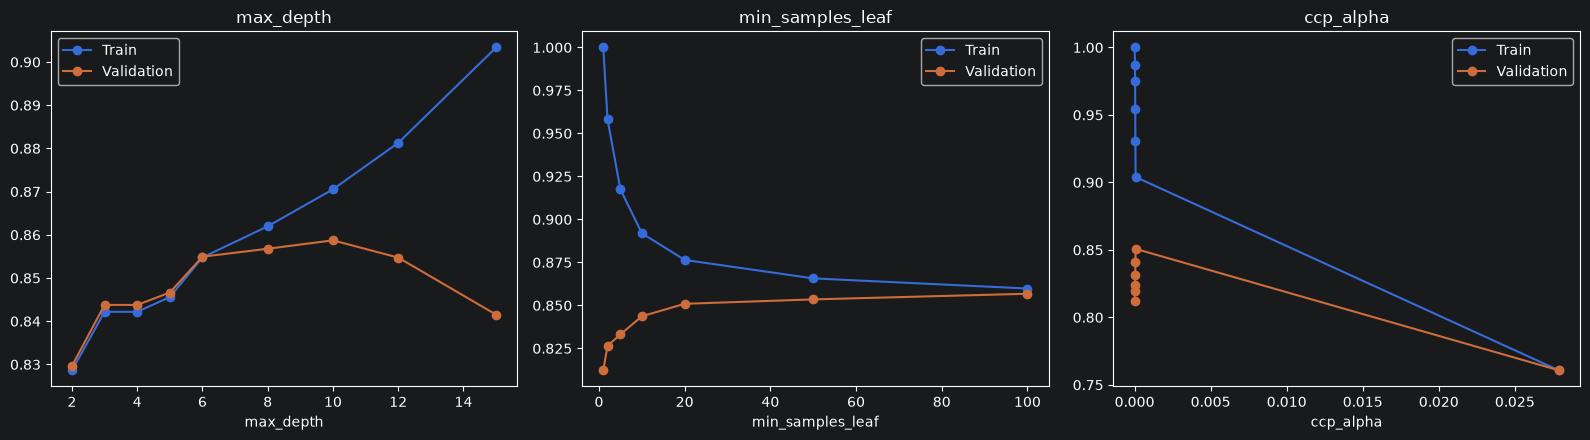

In [24]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Sweep 1: min_samples_leaf ---
leaf_values = [1, 2, 5, 10, 20, 50, 100]
leaf_results = []
for leaf in leaf_values:
    dt = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    cv_res = cross_validate(dt, X_train_processed, y_train, cv=cv, scoring=['accuracy', 'f1'], return_train_score=True)
    dt.fit(X_train_processed, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train_processed))
    val_acc = accuracy_score(y_val, dt.predict(X_val_processed))
    val_f1 = f1_score(y_val, dt.predict(X_val_processed))
    leaf_results.append({'min_samples_leaf': leaf,
                          'cv_acc_mean': cv_res['test_accuracy'].mean(), 'cv_acc_std': cv_res['test_accuracy'].std(),
                          'cv_f1_mean': cv_res['test_f1'].mean(), 'cv_f1_std': cv_res['test_f1'].std(),
                          'train_acc': train_acc, 'val_acc': val_acc, 'val_f1': val_f1})
leaf_df = pd.DataFrame(leaf_results)
print("\n=== min_samples_leaf sweep ===")
print(leaf_df.round(4))

# --- Sweep 2: ccp_alpha ---
# Rather than guessing alpha values blindly, get the tree's own real candidate
# alphas from its pruning path, then sample ~7 across that range
base_tree = DecisionTreeClassifier(random_state=42)
path = base_tree.cost_complexity_pruning_path(X_train_processed, y_train)
ccp_alphas = path.ccp_alphas
selected_alphas = np.unique(np.quantile(ccp_alphas[:-1], np.linspace(0, 1, 7)))  # exclude the trivial max alpha

alpha_results = []
for alpha in selected_alphas:
    dt = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    cv_res = cross_validate(dt, X_train_processed, y_train, cv=cv, scoring=['accuracy', 'f1'], return_train_score=True)
    dt.fit(X_train_processed, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train_processed))
    val_acc = accuracy_score(y_val, dt.predict(X_val_processed))
    val_f1 = f1_score(y_val, dt.predict(X_val_processed))
    alpha_results.append({'ccp_alpha': alpha,
                           'cv_acc_mean': cv_res['test_accuracy'].mean(), 'cv_acc_std': cv_res['test_accuracy'].std(),
                           'cv_f1_mean': cv_res['test_f1'].mean(), 'cv_f1_std': cv_res['test_f1'].std(),
                           'train_acc': train_acc, 'val_acc': val_acc, 'val_f1': val_f1})
alpha_df = pd.DataFrame(alpha_results)
print("\n=== ccp_alpha sweep ===")
print(alpha_df.round(4))

best_depth_row = results_df.loc[results_df['val_acc'].idxmax()]
best_leaf_row = leaf_df.loc[leaf_df['val_acc'].idxmax()]
best_alpha_row = alpha_df.loc[alpha_df['val_acc'].idxmax()]

print("\n=== Best setting per method ===")
print("Best by depth:    ", best_depth_row[['depth', 'val_acc', 'val_f1', 'train_acc']].to_dict())
print("Best by leaf size:", best_leaf_row[['min_samples_leaf', 'val_acc', 'val_f1', 'train_acc']].to_dict())
print("Best by ccp_alpha:", best_alpha_row[['ccp_alpha', 'val_acc', 'val_f1', 'train_acc']].to_dict())

# I asked Claude to make a visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(results_df['depth'], results_df['train_acc'], marker='o', label='Train')
axes[0].plot(results_df['depth'], results_df['val_acc'], marker='o', label='Validation')
axes[0].set_title('max_depth'); axes[0].set_xlabel('max_depth'); axes[0].legend()

axes[1].plot(leaf_df['min_samples_leaf'], leaf_df['train_acc'], marker='o', label='Train')
axes[1].plot(leaf_df['min_samples_leaf'], leaf_df['val_acc'], marker='o', label='Validation')
axes[1].set_title('min_samples_leaf'); axes[1].set_xlabel('min_samples_leaf'); axes[1].legend()

axes[2].plot(alpha_df['ccp_alpha'], alpha_df['train_acc'], marker='o', label='Train')
axes[2].plot(alpha_df['ccp_alpha'], alpha_df['val_acc'], marker='o', label='Validation')
axes[2].set_title('ccp_alpha'); axes[2].set_xlabel('ccp_alpha'); axes[2].legend()

plt.tight_layout()
plt.show()

The three plots look different because each hyperparameter controls complexity in a
different way.

max_depth shows a clear peak: validation performance rises, peaks around depth 10,
then drops as the tree starts to overfit.

min_samples_leaf shows no peak in the range we tested. Validation keeps improving all
the way up to 100, meaning we might have found an even better setting if we'd tested
higher values. (In some ways it looks like it is converging)

ccp_alpha shows a steady decline once alpha grows past a very small value. Train and
validation drop together at the far right, meaning larger alpha values just destroy
the tree's ability to tell the classes apart. Only a narrow range close to zero is
actually useful.

Even though the plots look different, all three methods land on a similar best
validation accuracy (0.859, 0.857, and 0.851). But min_samples_leaf=100 has the
smallest gap between train and validation accuracy (0.003), which makes it the most
reliable choice out of the three.

### Q2.5

Retrain the Decision Tree with class weight="balanced" and compare it against
the unweighted version on the validation set (precision, recall, F1 for the minority
class). Discuss why this matters for an imbalanced dataset.

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# --- Unweighted (best setting from Q2.4) ---
dt_unweighted = DecisionTreeClassifier(min_samples_leaf=100, random_state=42)
dt_unweighted.fit(X_train_processed, y_train)
pred_unweighted = dt_unweighted.predict(X_val_processed)

# --- Balanced ---
dt_balanced = DecisionTreeClassifier(min_samples_leaf=100, random_state=42, class_weight='balanced')
dt_balanced.fit(X_train_processed, y_train)
pred_balanced = dt_balanced.predict(X_val_processed)

# pos_label=1 = the minority class (>50K)
for name, pred in [('Unweighted', pred_unweighted), ('Balanced', pred_balanced)]:
    p = precision_score(y_val, pred, pos_label=1)
    r = recall_score(y_val, pred, pos_label=1)
    f1 = f1_score(y_val, pred, pos_label=1)
    print(f"{name}: precision={p:.4f}  recall={r:.4f}  f1={f1:.4f}")

Unweighted: precision=0.7543  recall=0.5952  f1=0.6654
Balanced: precision=0.5514  recall=0.8490  f1=0.6686


class_weight='balanced' trades precision for recall on the minority class: recall
rises from 0.595 to 0.849, while precision falls from 0.754 to 0.551. F1 stays
roughly the same (0.665 vs 0.669), showing this is a genuine trade-off rather than a
straightforward improvement.

This matters because which trade-off is preferable depends on the real-world cost of
each type of error. If missing a true high earner (a false negative) is more costly
than incorrectly flagging someone as a high earner (a false positive) - for example,
in a use case like loan eligibility screening or targeted benefits outreach - the
balanced model is clearly preferable, since it catches far more of the true >50K
group. If false positives are more costly instead, the unweighted model's higher
precision would be preferred. Since F1 alone doesn't reveal this trade-off (it looks
almost unchanged), it's important to examine precision and recall separately, rather
than relying on a single combined metric, when deciding which model fits the actual
goal.


## Exercise-3: Support Vector Machines (SVM) 
### Q3.1 
Train a linear SVM (kernel="linear") on a suitable subsample of the training
set (justify your sample size choice given SVM training complexity) and evaluate
on the validation set using the original 5 splits from Exercise 2. Report accuracy
mean, std, and plot the ROC curve for each split. 

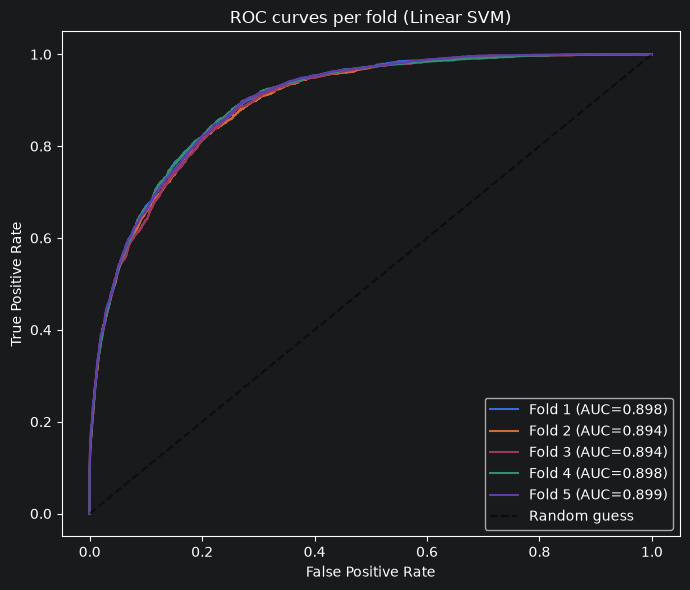

Accuracy: mean=0.8481  std=0.0010


In [26]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

X_sub, _, y_sub, _ = train_test_split(
    X_train_processed, y_train, train_size=1500, stratify=y_train, random_state=42
)

y_sub = np.asarray(y_sub)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
plt.figure(figsize=(7, 6))

for fold, (train_idx, _) in enumerate(cv.split(X_sub, y_sub), start=1):
    svm = SVC(kernel='linear', random_state=42)
    svm.fit(X_sub[train_idx], y_sub[train_idx])  

    val_pred = svm.predict(X_val_processed)
    acc = accuracy_score(y_val, val_pred)
    accuracies.append(acc)

    scores = svm.decision_function(X_val_processed)
    fpr, tpr, _ = roc_curve(y_val, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Fold {fold} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves per fold (Linear SVM)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Accuracy: mean={np.mean(accuracies):.4f}  std={np.std(accuracies):.4f}")

The linear SVM achieves a mean validation accuracy of 0.8481 (std=0.0010) across the
5 folds, essentially identical to our best Decision Tree results (~0.856-0.859),
with almost no variation between folds. Showing this performance is highly stable
regardless of which specific training subsample or fold split was used.

The ROC curves confirm strong, consistent discriminative ability: all 5 folds produce
nearly overlapping curves with AUC between 0.894 and 0.899. Since the curve bows
sharply above the diagonal (reaching about 80% TPR at only about 20% FPR), the model can
identify most true >50K earners while keeping false positives relatively low, a
result far better than random guessing, and comparable in quality to the
accuracy-based results from the Decision Tree section.

### Q3.2 
Train an RBF kernel SVM under the same conditions. Compare its performance
to the linear kernel using validation accuracy, F1-score, and ROC-AUC. Plot ROC
curves for both models on the same axes.

linear    acc=0.8481±0.0010  f1=0.6545±0.0037  auc=0.8967±0.0020
rbf       acc=0.8525±0.0015  f1=0.6466±0.0063  auc=0.8887±0.0026


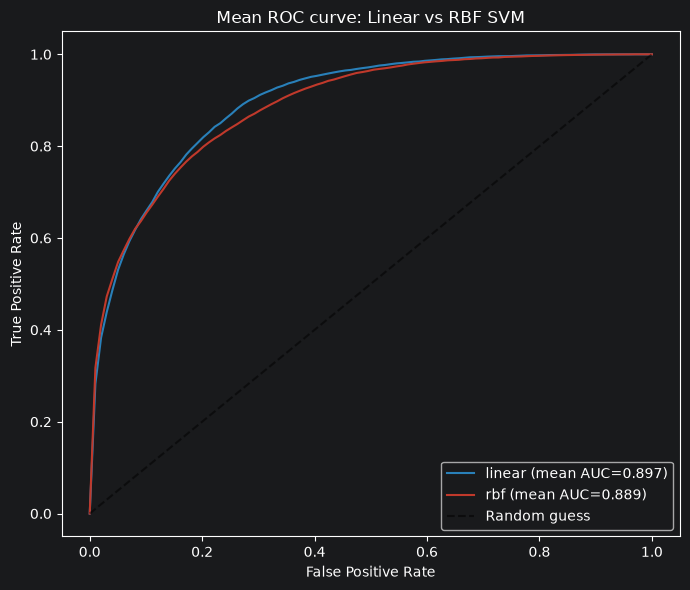

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc

# reuse the SAME X_sub, y_sub, cv from Q3.1 (same conditions)
mean_fpr = np.linspace(0, 1, 100)

results = {'linear': {'acc': [], 'f1': [], 'auc': [], 'tprs': []},
           'rbf':    {'acc': [], 'f1': [], 'auc': [], 'tprs': []}}

for kernel in ['linear', 'rbf']:
    for fold, (train_idx, _) in enumerate(cv.split(X_sub, y_sub), start=1):
        svm = SVC(kernel=kernel, random_state=42)
        svm.fit(X_sub[train_idx], y_sub[train_idx])

        pred = svm.predict(X_val_processed)
        acc = accuracy_score(y_val, pred)
        f1 = f1_score(y_val, pred)

        scores = svm.decision_function(X_val_processed)
        fpr, tpr, _ = roc_curve(y_val, scores)
        roc_auc = auc(fpr, tpr)

        # interpolate this fold's curve onto a common FPR grid, so folds can be averaged
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0

        results[kernel]['acc'].append(acc)
        results[kernel]['f1'].append(f1)
        results[kernel]['auc'].append(roc_auc)
        results[kernel]['tprs'].append(interp_tpr)

# --- Print comparison table ---
for kernel in ['linear', 'rbf']:
    acc_mean, acc_std = np.mean(results[kernel]['acc']), np.std(results[kernel]['acc'])
    f1_mean, f1_std = np.mean(results[kernel]['f1']), np.std(results[kernel]['f1'])
    auc_mean, auc_std = np.mean(results[kernel]['auc']), np.std(results[kernel]['auc'])
    print(f"{kernel:8s}  acc={acc_mean:.4f}±{acc_std:.4f}  f1={f1_mean:.4f}±{f1_std:.4f}  auc={auc_mean:.4f}±{auc_std:.4f}")

# --- Plot both models' MEAN ROC curve (averaged across the 5 folds) on one axes ---
plt.figure(figsize=(7, 6))
for kernel, color in [('linear', '#2980b9'), ('rbf', '#c0392b')]:
    mean_tpr = np.mean(results[kernel]['tprs'], axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(results[kernel]['auc'])
    plt.plot(mean_fpr, mean_tpr, color=color, label=f'{kernel} (mean AUC={mean_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Mean ROC curve: Linear vs RBF SVM')
plt.legend()
plt.tight_layout()
plt.show()



Comparing the two kernels: RBF has slightly higher accuracy (0.8525 vs 0.8481), but
Linear SVM does better on F1 (0.6545 vs 0.6466) and ROC-AUC (0.8967 vs 0.8887). Since
F1 and AUC matter more than plain accuracy here, Linear SVM looks like the slightly
better choice overall.

This also suggests the data is mostly linearly separable already. If the real
boundary between the two income classes needed a curved shape, RBF's extra
flexibility should have given a clear improvement. Instead, both kernels perform
almost the same, meaning the added complexity of RBF isn't really paying off here,
similar to how a deeper Decision Tree didn't clearly beat a shallower one earlier.

### Q3.3
Experiment with different values of C (regularization strength, at least 6 values
spanning several orders of magnitude). Use the validation set to select the best C.
Report results as a plot of accuracy and F1-score vs. C, and explain the trend in
terms of margin width and number of support vectors. 

          C  accuracy        f1  n_support_vectors
0     0.001  0.783272  0.174015                721
1     0.010  0.828931  0.506643                621
2     0.100  0.850020  0.648934                546
3     1.000  0.849201  0.658791                513
4    10.000  0.849201  0.661923                505
5   100.000  0.849304  0.662075                505
6  1000.000  0.849509  0.662844                506


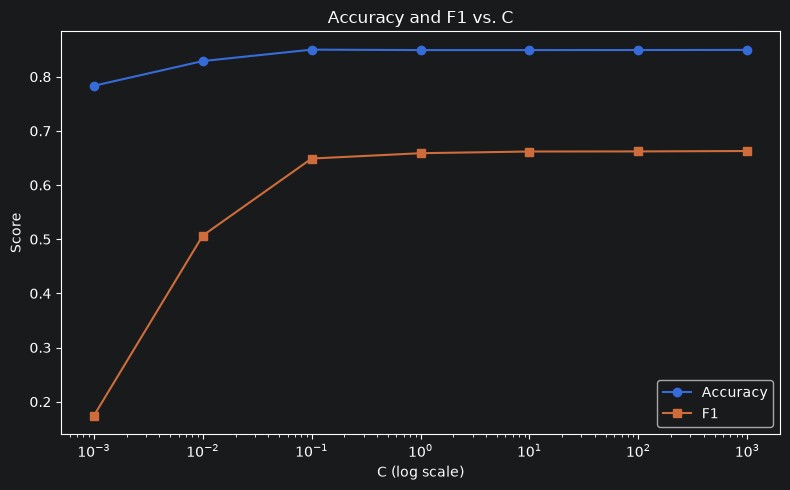

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
results = []

for C in C_values:
    svm = SVC(kernel='linear', C=C, random_state=42)
    svm.fit(X_sub, y_sub)   # same subsample as Q3.1/Q3.2

    pred = svm.predict(X_val_processed)
    acc = accuracy_score(y_val, pred)
    f1 = f1_score(y_val, pred)
    n_sv = svm.n_support_.sum()  # Tells us how many training points ended up as support vectors

    results.append({'C': C, 'accuracy': acc, 'f1': f1, 'n_support_vectors': n_sv})

results_df = pd.DataFrame(results)
print(results_df)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(results_df['C'], results_df['accuracy'], marker='o', label='Accuracy')
ax1.plot(results_df['C'], results_df['f1'], marker='s', label='F1')
ax1.set_xscale('log')   # essential: C spans several orders of magnitude
ax1.set_xlabel('C (log scale)')
ax1.set_ylabel('Score')
ax1.set_title('Accuracy and F1 vs. C')
ax1.legend()
plt.tight_layout()
plt.show()

Accuracy and F1 both rise sharply as C goes from 0.001 to 0.1, then flatten out: from
C=0.1 to C=1000, accuracy stays around 0.849 to 0.850 and F1 around 0.649 to 0.663,
with no real improvement after that. We pick C=0.1 as the best value, since it
already gets the same performance as much larger C values, while keeping the widest
margin among the good options.

This matches the margin and support vector idea directly. As C goes from 0.001 to
1000, the number of support vectors drops from 721 to 505, meaning the margin keeps
shrinking. A higher C punishes margin violations more, forcing the boundary to fit
the training data more tightly. At very small C, the margin is so wide that it barely
separates the two classes (F1 as low as 0.17), which is underfitting. Once C reaches
about 0.1, the margin is narrow enough to separate the classes well, and shrinking it
further doesn't help anymore, which is why performance flattens out.

Unlike the Decision Tree depth sweep, performance never drops again at high C, so
overfitting doesn't seem to be a real problem here, even with a very narrow margin.
This fits with what we saw in Q3.2: the data seems to be mostly linearly separable
already.

### Q3.4
Experiment with different γ values for the RBF kernel (at least 6 values). Discuss
the effect on the bias-variance trade-off for all experimented values, referencing the
number of support vectors at each setting. Select the best γ using the validation
set and report performance.

      gamma  train_acc   val_acc    val_f1  n_support_vectors
0    0.0001   0.760667  0.760749  0.000000                718
1    0.0010   0.760667  0.760749  0.000000                721
2    0.0100   0.808000  0.805283  0.318768                713
3    0.1000   0.836667  0.832310  0.512210                727
4    1.0000   0.760667  0.760749  0.000000               1379
5   10.0000   0.760667  0.760749  0.000000               1499
6  100.0000   0.760667  0.760749  0.000000               1500


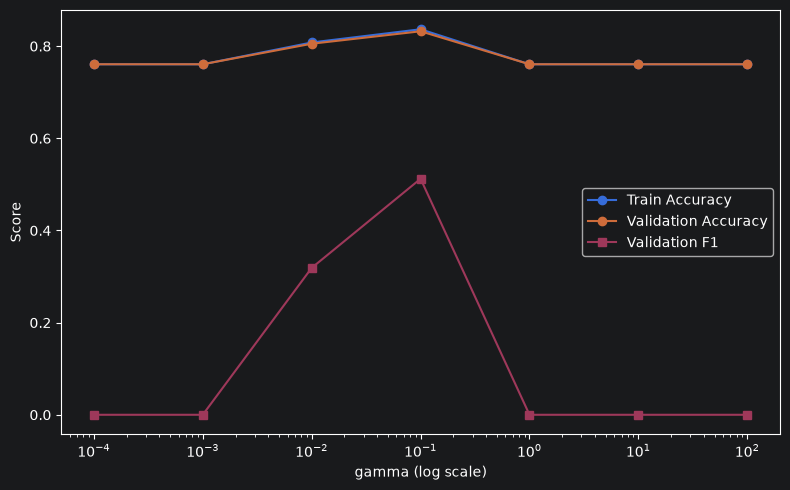

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
results = []

for g in gamma_values:
    svm = SVC(kernel='rbf', gamma=g, random_state=42, C=0.1)  # using best C from Q3.3
    svm.fit(X_sub, y_sub)

    train_acc = accuracy_score(y_sub, svm.predict(X_sub))
    val_pred = svm.predict(X_val_processed)
    val_acc = accuracy_score(y_val, val_pred)
    val_f1 = f1_score(y_val, val_pred)
    n_sv = svm.n_support_.sum()

    results.append({'gamma': g, 'train_acc': train_acc, 'val_acc': val_acc, 'val_f1': val_f1, 'n_support_vectors': n_sv})

results_df = pd.DataFrame(results)
print(results_df)

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(results_df['gamma'], results_df['train_acc'], marker='o', label='Train Accuracy')
ax1.plot(results_df['gamma'], results_df['val_acc'], marker='o', label='Validation Accuracy')
ax1.plot(results_df['gamma'], results_df['val_f1'], marker='s', label='Validation F1')
ax1.set_xscale('log')
ax1.set_xlabel('gamma (log scale)')
ax1.set_ylabel('Score')
ax1.legend()
plt.tight_layout()
plt.show()

The best gamma is 0.1, with the highest validation accuracy (0.832) and F1 (0.512).

Gamma controls how far each training point's influence reaches. The results show three
clear stages:

**Very low gamma (0.0001 to 0.001) = underfitting:** F1 is 0 and accuracy is stuck at
0.76, which is just the model guessing "<=50K" for everyone. Each point's influence is
spread too wide, so the boundary is too smooth to separate the two classes at all.
Support vectors stay moderate (about 720).

**Gamma around 0.01 to 0.1 = the sweet spot:** the boundary is now flexible enough to
actually separate the classes, giving the best accuracy and F1. Support vectors are
still moderate (around 713 to 727).

**High gamma (1 to 100) =  overfitting:** the number of support vectors jumps to almost
the entire training set (up to 1500). This happens because each point's influence
becomes so narrow that the model basically memorizes every single point. It fits the
training data but generalizes to nothing, so F1 drops back to 0 and accuracy falls
back to 0.76.

In short: the support vector count stays moderate when the model works well, but shoots
up to the full training set size exactly when it starts overfitting. This makes it a
clear signal of when gamma has become too high.


## Exercise-4: Model Comparison
### Q4.1
Compare Decision Tree and SVM results from the training set (cross-validation
mean ± std) and validation set, using accuracy, F1-score, and ROC-AUC. Plot the
performance comparison (e.g., grouped bar charts, ROC curves overlaid). Which
model generalizes better, and on what evidence?

           model  cv_acc_mean  cv_acc_std  cv_f1_mean  cv_f1_std  cv_auc_mean  cv_auc_std  val_acc  val_f1  val_auc
0  Decision Tree       0.7947      0.0153      0.5068     0.0427       0.8383      0.0226   0.8233  0.5800   0.8511
1     Linear SVM       0.8567      0.0170      0.6608     0.0490       0.9014      0.0052   0.8500  0.6489   0.8976


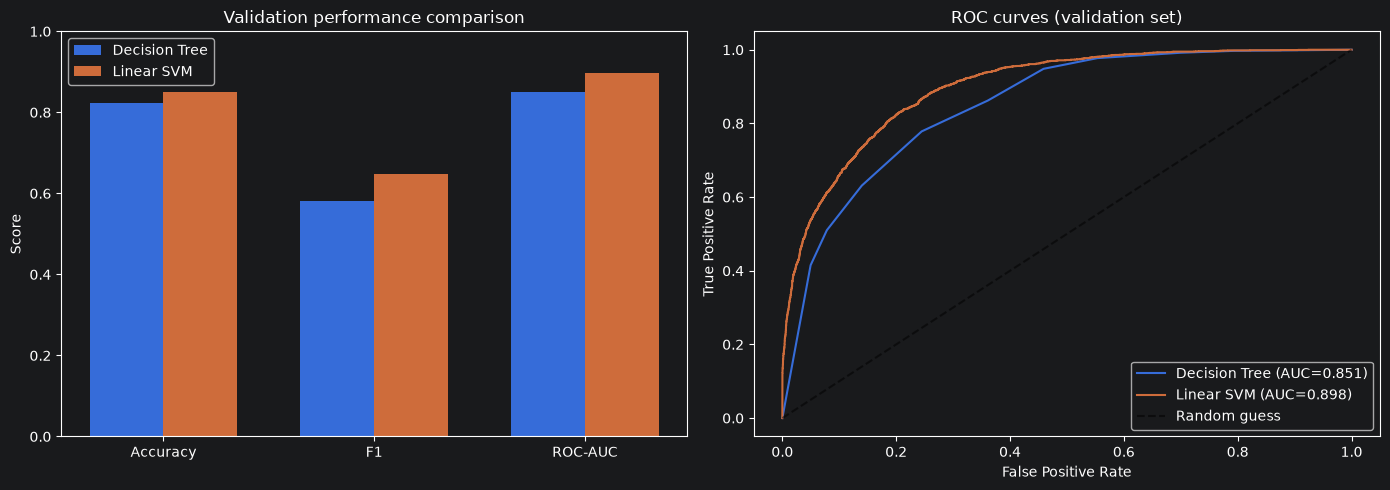

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# using each models best settings
models = {
    'Decision Tree': DecisionTreeClassifier(min_samples_leaf=100, random_state=42),   # best from Q2.4
    'Linear SVM': SVC(kernel='linear', C=0.1, random_state=42),                        # best from Q3.3
}

summary = []
roc_data = {}

for name, model in models.items():
    # --- 5-fold CV on the training subsample ---
    cv_res = cross_validate(model, X_sub, y_sub, cv=cv, scoring=['accuracy', 'f1', 'roc_auc'])

    # --- fit on full subsample, evaluate on validation set ---
    model.fit(X_sub, y_sub)
    val_pred = model.predict(X_val_processed)
    val_acc = accuracy_score(y_val, val_pred)
    val_f1 = f1_score(y_val, val_pred)

    # Decision Tree has no decision_function, so fall back to predict_proba for it
    if hasattr(model, "decision_function"):
        val_scores = model.decision_function(X_val_processed)
    else:
        val_scores = model.predict_proba(X_val_processed)[:, 1]   # probability of the positive class (>50K)

    val_auc = roc_auc_score(y_val, val_scores)

    summary.append({
        'model': name,
        'cv_acc_mean': cv_res['test_accuracy'].mean(), 'cv_acc_std': cv_res['test_accuracy'].std(),
        'cv_f1_mean': cv_res['test_f1'].mean(), 'cv_f1_std': cv_res['test_f1'].std(),
        'cv_auc_mean': cv_res['test_roc_auc'].mean(), 'cv_auc_std': cv_res['test_roc_auc'].std(),
        'val_acc': val_acc, 'val_f1': val_f1, 'val_auc': val_auc,
    })
    fpr, tpr, _ = roc_curve(y_val, val_scores)
    roc_data[name] = (fpr, tpr, auc(fpr, tpr))

summary_df = pd.DataFrame(summary)
print(summary_df.round(4).to_string())

# --- Plot 1: grouped bar chart (validation metrics) ---
metrics = ['val_acc', 'val_f1', 'val_auc']
labels = ['Accuracy', 'F1', 'ROC-AUC']
x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(x - width/2, summary_df.loc[0, metrics], width, label=summary_df.loc[0, 'model'])
ax1.bar(x + width/2, summary_df.loc[1, metrics], width, label=summary_df.loc[1, 'model'])
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel('Score'); ax1.set_title('Validation performance comparison')
ax1.set_ylim(0, 1); ax1.legend()

# --- Plot 2: overlaid ROC curves ---
for name, (fpr, tpr, roc_auc) in roc_data.items():
    ax2.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random guess')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC curves (validation set)'); ax2.legend()

plt.tight_layout()
plt.show()

The Linear SVM performs better than the Decision Tree. It wins on every metric as
illustrated on the plots (Cross validation and validation set ):

- Cross validation: SVM beats the tree on accuracy (0.857 vs 0.795), F1 (0.661 vs
  0.507), and ROC-AUC (0.901 vs 0.838).
- Validation set: same result, accuracy (0.850 vs 0.823), F1 (0.649 vs 0.580), and
  ROC-AUC (0.898 vs 0.851).
- The ROC plot shows this clearly: the SVM's curve sits above the tree's the whole
  way, with a bigger area underneath (AUC 0.898 vs 0.851).

The biggest gaps are in F1 and AUC, which are the metrics that matter most here since
only about 24% of people earn >50K. This means the SVM is noticeably better at
correctly finding the minority (>50K) group, not just the majority.

The SVM also outperforms in stability. Its cross validation results vary less between folds
(especially AUC: 0.005 vs 0.023 std), so its performance depends less on which fold is
used.

For both models, the cross validation and validation scores are close to each other
(for example SVM: 0.857 vs 0.850 accuracy), so neither is badly overfit. But overall,
the Linear SVM is clearly the better and a more robust model. This also fits what we
found in Q3.2, that the data is mostly linearly separable, which is exactly where a
linear SVM performs best.


### Q4.2
Discuss the trade-off between usability (interpretability, training/inference cost)
and accuracy for this dataset. Which model would you recommend for a decision-
support system used by a bank or employer, and why? Use Fβ score analysis with
at least two values of β to justify your choice, given the cost asymmetry of false
positives vs. false negatives in this domain.

In [32]:
import numpy as np
from sklearn.metrics import fbeta_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# best models from earlier
dt = DecisionTreeClassifier(min_samples_leaf=100, random_state=42).fit(X_sub, y_sub)
svm = SVC(kernel='linear', C=0.1, random_state=42).fit(X_sub, y_sub)

dt_pred = dt.predict(X_val_processed)
svm_pred = svm.predict(X_val_processed)

print(f"{'beta':<6}{'Decision Tree':<16}{'Linear SVM':<16}")
for beta in [0.5, 1, 2]:
    dt_fb = fbeta_score(y_val, dt_pred, beta=beta)
    svm_fb = fbeta_score(y_val, svm_pred, beta=beta)
    print(f"{beta:<6}{dt_fb:<16.4f}{svm_fb:<16.4f}")

beta  Decision Tree   Linear SVM      
0.5   0.6321          0.6993          
1     0.5800          0.6489          
2     0.5359          0.6053          
